In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.facecolor"  : "white",
    "axes.facecolor"    : "#F8F9FA",
    "axes.grid"         : True,
    "grid.alpha"        : 0.3,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "font.family"       : "DejaVu Sans",
    "axes.labelsize"    : 11,
    "axes.titlesize"    : 12,
    "axes.titleweight"  : "bold",
})

TEAM_COLORS = {
    "MI"  : "#004BA0", "CSK" : "#F9CD05", "RCB" : "#EC1C24",
    "KKR" : "#3A225D", "SRH" : "#FF822A", "RR"  : "#254AA5",
    "GT"  : "#1C1C1C", "LSG" : "#A4262C", "DC"  : "#0078BC",
    "PBKS": "#AA4545"
}

In [2]:
bbb  = pd.read_csv(r"C:\Users\saket\Downloads\Data Visualization lab\Project_cleaned\cleaned_bbb.csv")
mat  = pd.read_csv(r"C:\Users\saket\Downloads\Data Visualization lab\Project_cleaned\cleaned_matches.csv")
bat  = pd.read_csv(r"C:\Users\saket\Downloads\Data Visualization lab\Project_cleaned\cleaned_batters.csv")
bowl = pd.read_csv(r"C:\Users\saket\Downloads\Data Visualization lab\Project_cleaned\cleaned_bowlers.csv")
ar   = pd.read_csv(r"C:\Users\saket\Downloads\Data Visualization lab\Project_cleaned\cleaned_allrounders.csv")
vn   = pd.read_csv(r"C:\Users\saket\Downloads\Data Visualization lab\Project_cleaned\cleaned_venue.csv")

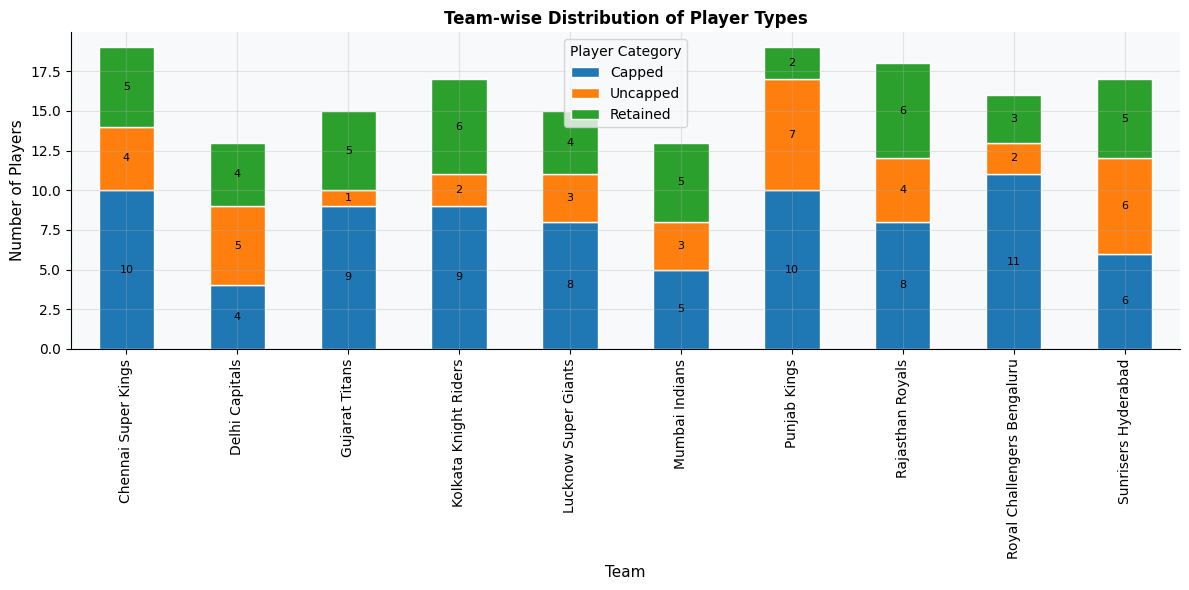

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Combine all players
all_players = pd.concat([
    bat[["Player","Team","Capped","Status"]],
    bowl[["Player","Team","Capped","Status"]],
    ar[["Player","Team","Capped","Status"]]
])

# Create unified category
def get_category(row):
    if row["Status"] == "Retained":
        return "Retained"
    return row["Capped"]  # Capped / Uncapped

all_players["Category"] = all_players.apply(get_category, axis=1)

# Count per team
team_cat = all_players.groupby(["Team","Category"]).size().unstack(fill_value=0)

# Ensure column order
for col in ["Capped","Uncapped","Retained"]:
    if col not in team_cat.columns:
        team_cat[col] = 0

team_cat = team_cat[["Capped","Uncapped","Retained"]]

# ---- Plot ----
team_cat.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6),
    edgecolor="white"
)

plt.title("Team-wise Distribution of Player Types")
plt.xlabel("Team")
plt.ylabel("Number of Players")
plt.legend(title="Player Category")

# Value labels
for i, row in enumerate(team_cat.values):
    bottom = 0
    for val in row:
        if val > 0:
            plt.text(i, bottom + val/2, str(val),
                     ha='center', va='center', fontsize=8)
        bottom += val

plt.tight_layout()
plt.show()

In [4]:
TEAM_COLORS = {
    "MI":"#004BA0",
    "CSK":"#FECB00",
    "RCB":"#EC1C24",
    "KKR":"#3A225D",
    "SRH":"#FF822A",
    "RR":"#EA1A85",
    "GT":"#1C1C1C",
    "LSG":"#00AEEF",
    "DC":"#17449B",
    "PBKS":"#D71920"
}

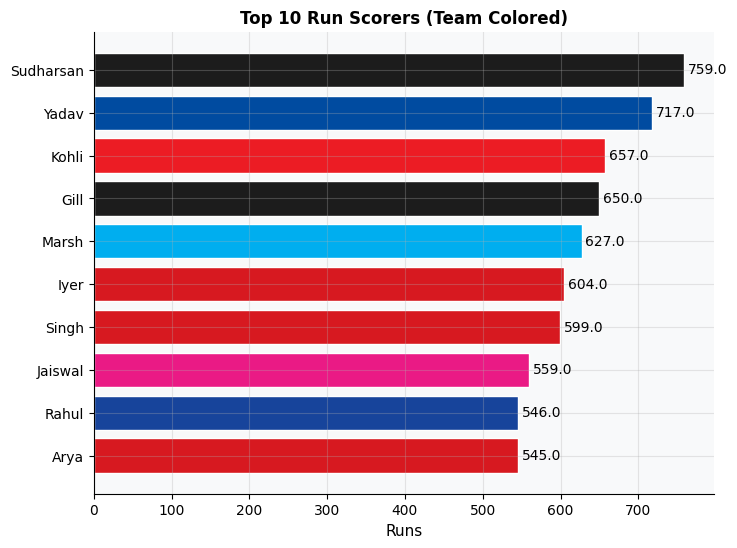

In [5]:
plt.figure(figsize=(8,6))

all_bat = pd.concat([
    bat[["Player","Team","RUNS","Price_Cr"]],
    ar[["Player","Team","RUNS","Price_Cr"]]
], ignore_index=True)

top10 = all_bat.nlargest(10, "RUNS")[
    ["Player","Team","RUNS","Price_Cr"]
].reset_index(drop=True).sort_values("RUNS", ascending=False)

top10["short"] = top10["Player"].apply(lambda x: x.split()[-1])

# ---- Fix team names ----
team_map = {
    "Mumbai Indians":"MI","Chennai Super Kings":"CSK",
    "Royal Challengers Bengaluru":"RCB","Kolkata Knight Riders":"KKR",
    "Sunrisers Hyderabad":"SRH","Rajasthan Royals":"RR",
    "Gujarat Titans":"GT","Lucknow Super Giants":"LSG",
    "Delhi Capitals":"DC","Punjab Kings":"PBKS"
}

top10["Team_abbr"] = top10["Team"].map(team_map).fillna(top10["Team"])

# ---- Apply colors ----
cols = [TEAM_COLORS.get(t,"#888") for t in top10["Team_abbr"]]

bars = plt.barh(top10["short"], top10["RUNS"], color=cols, edgecolor="white")

# Labels
for bar, val in zip(bars, top10["RUNS"]):
    plt.text(val+5, bar.get_y()+bar.get_height()/2, str(val), va="center")

plt.xlabel("Runs")
plt.title("Top 10 Run Scorers (Team Colored)")
plt.gca().invert_yaxis()

plt.show()

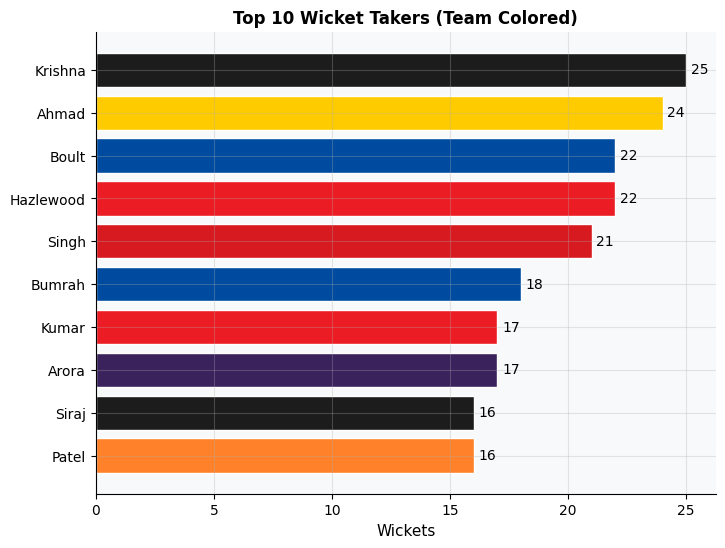

In [6]:
plt.figure(figsize=(8,6))

top10b = bowl.nlargest(10, "WKTS")[["Player","Team","WKTS","ECON"]].reset_index(drop=True)
top10b["short"] = top10b["Player"].apply(lambda x: x.split()[-1])

# ---- Team mapping ----
team_map = {
    "Mumbai Indians":"MI","Chennai Super Kings":"CSK",
    "Royal Challengers Bengaluru":"RCB","Kolkata Knight Riders":"KKR",
    "Sunrisers Hyderabad":"SRH","Rajasthan Royals":"RR",
    "Gujarat Titans":"GT","Lucknow Super Giants":"LSG",
    "Delhi Capitals":"DC","Punjab Kings":"PBKS"
}

top10b["Team_abbr"] = top10b["Team"].map(team_map).fillna(top10b["Team"])

# ---- Apply team colors ----
cols = [TEAM_COLORS.get(t, "#888") for t in top10b["Team_abbr"]]

bars = plt.barh(top10b["short"], top10b["WKTS"], color=cols, edgecolor="white")

# ---- Value labels ----
for bar, val in zip(bars, top10b["WKTS"]):
    plt.text(val + 0.2, bar.get_y() + bar.get_height()/2,
             str(val), va="center")

plt.xlabel("Wickets")
plt.title("Top 10 Wicket Takers (Team Colored)")
plt.gca().invert_yaxis()

plt.show()

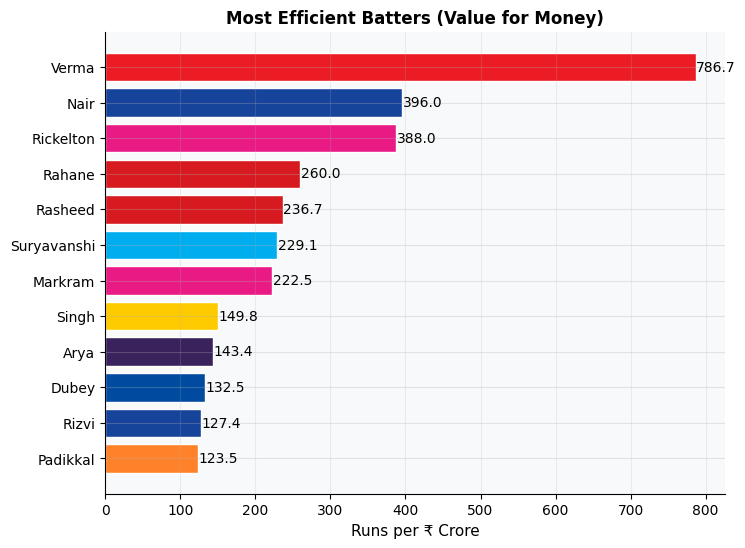

In [7]:
plt.figure(figsize=(8,6))

eff = bat.dropna(subset=["Price_Cr"]).query("Price_Cr > 0").copy()
eff["runs_per_cr"] = (eff["RUNS"] / eff["Price_Cr"]).round(1)

top_eff = eff.nlargest(12, "runs_per_cr").copy()

# ---- Team mapping ----
team_map = {
    "Mumbai Indians":"MI","Chennai Super Kings":"CSK",
    "Royal Challengers Bengaluru":"RCB","Kolkata Knight Riders":"KKR",
    "Sunrisers Hyderabad":"SRH","Rajasthan Royals":"RR",
    "Gujarat Titans":"GT","Lucknow Super Giants":"LSG",
    "Delhi Capitals":"DC","Punjab Kings":"PBKS"
}

top_eff["Team_abbr"] = top_eff["Team"].map(team_map).fillna(top_eff["Team"])

# ---- Apply colors ----
cols = [TEAM_COLORS.get(t, "#888") for t in top_eff["Team_abbr"]]

# ---- Reverse order for proper ranking ----
top_eff = top_eff.iloc[::-1]

bars = plt.barh(
    top_eff["Player"].apply(lambda x: x.split()[-1]),
    top_eff["runs_per_cr"],
    color=cols,
    edgecolor="white"
)

# ---- Labels ----
for bar, val in zip(bars, top_eff["runs_per_cr"]):
    plt.text(val + 0.5,
             bar.get_y() + bar.get_height()/2,
             f"{val}", va="center")

plt.xlabel("Runs per ₹ Crore")
plt.title("Most Efficient Batters (Value for Money)")
plt.grid(axis="x", alpha=0.2)

plt.show()

In [10]:
all_bat = pd.concat([
    bat[["Player","Team","RUNS","BF","AVG","SR","INN","Price_Cr",
         "FOURS","SIXES","HUNDREDS","FIFTIES"]],
    ar[["Player","Team","RUNS","BF","Bat_AVG","Bat_SR","Bat_INN","Price_Cr",
        "FOURS","SIXES","HUNDREDS","FIFTIES"]].rename(
        columns={"Bat_AVG":"AVG","Bat_SR":"SR","Bat_INN":"INN"})
], ignore_index=True).dropna(subset=["RUNS"])
all_bat["Abbr"] = all_bat["Team"].map(team_map).fillna(all_bat["Team"])
 
bowl["Abbr"] = bowl["Team"].map(team_map).fillna(bowl["Team"])
 
# Price lookup for BBB-derived metrics
price_lookup = pd.concat([
    bat[["Player","Price_Cr"]],
    bowl[["Player","Price_Cr"]],
    ar[["Player","Price_Cr"]]
]).dropna().groupby("Player")["Price_Cr"].first()


In [19]:
import plotly.graph_objects as go

# ---- Batter score ----
bs = all_bat.dropna(subset=["Price_Cr","RUNS","SR","AVG"]).copy()

for col in ["RUNS","SR","AVG"]:
    mn, mx = bs[col].min(), bs[col].max()
    bs[f"{col}_n"] = (bs[col]-mn)/(mx-mn) if mx > mn else 0

bs["perf"] = bs["RUNS_n"]*0.5 + bs["SR_n"]*0.3 + bs["AVG_n"]*0.2

p_mn, p_mx = bs["Price_Cr"].min(), bs["Price_Cr"].max()
bs["price_n"] = (bs["Price_Cr"]-p_mn)/(p_mx-p_mn)

# ---- Plot ----
fig = go.Figure()

med_price = bs["price_n"].median()
med_perf  = bs["perf"].median()

for _, row in bs.iterrows():
    team  = row.get("Abbr", "")
    color = TEAM_COLORS.get(team, "#888")
    label = row["Player"].split()[-1]

    fig.add_trace(go.Scatter(
        x=[row["price_n"]],
        y=[row["perf"]],
        mode="markers+text",
        marker=dict(size=10, color=color, line=dict(width=1, color="white")),
        text=[label],
        textposition="top center",
        showlegend=False
    ))

# Quadrant lines
fig.add_shape(type="line", x0=med_price, x1=med_price, y0=0, y1=1,
              line=dict(dash="dash", color="gray"))

fig.add_shape(type="line", x0=0, x1=1, y0=med_perf, y1=med_perf,
              line=dict(dash="dash", color="gray"))

# Quadrant labels
fig.add_annotation(x=0.1, y=0.9, text="🟢 UNDERVALUED", showarrow=False)
fig.add_annotation(x=0.75, y=0.9, text="🔵 STAR PLAYERS", showarrow=False)
fig.add_annotation(x=0.1, y=0.1, text="⚪ BARGAIN", showarrow=False)
fig.add_annotation(x=0.75, y=0.1, text="🔴 OVERVALUED", showarrow=False)

fig.update_layout(
    title="Batters — Price vs Performance Quadrant",
    xaxis_title="Normalized Price",
    yaxis_title="Performance Score",
    height=900,
    width=1300
)

fig.show()

In [11]:
all_bat.head()

,Player,Team,RUNS,BF,AVG,SR,INN,Price_Cr,FOURS,SIXES,HUNDREDS,FIFTIES,Abbr
0,Rishabh Pant,Lucknow Super Giants,269.0,202.0,24.45,133.17,13.0,27.00,23.0,16.0,1.0,1.0,LSG
1,Shreyas Iyer,Punjab Kings,604.0,345.0,50.33,175.07,17.0,26.75,43.0,39.0,0.0,6.0,PBKS
2,Heinrich Klaasen,Sunrisers Hyderabad,487.0,282.0,44.27,172.70,13.0,23.00,42.0,25.0,1.0,1.0,SRH
3,Nicholas Pooran,Lucknow Super Giants,524.0,267.0,43.67,196.25,14.0,21.00,45.0,40.0,0.0,5.0,LSG
4,Virat Kohli,Royal Challengers Bengaluru,657.0,454.0,54.75,144.71,15.0,21.00,66.0,19.0,0.0,8.0,RCB


In [18]:
bws = bowl.dropna(subset=["Price_Cr","WKTS","ECON","SR"]).copy()

bws["econ_inv"] = 1/bws["ECON"].replace(0, np.nan)
bws["sr_inv"]   = 1/bws["SR"].replace(0, np.nan)

for col in ["WKTS","econ_inv","sr_inv"]:
    mn, mx = bws[col].min(), bws[col].max()
    bws[f"{col}_n"] = (bws[col]-mn)/(mx-mn) if mx > mn else 0

bws["perf"] = (
    bws["WKTS_n"]*0.5 +
    bws["econ_inv_n"]*0.3 +
    bws["sr_inv_n"]*0.2
)

p_mn2, p_mx2 = bws["Price_Cr"].min(), bws["Price_Cr"].max()
bws["price_n"] = (bws["Price_Cr"]-p_mn2)/(p_mx2-p_mn2)

# ---- Plot ----
fig = go.Figure()

med_price = bws["price_n"].median()
med_perf  = bws["perf"].median()

for _, row in bws.iterrows():
    team  = row.get("Abbr", "")
    color = TEAM_COLORS.get(team, "#888")
    label = row["Player"].split()[-1]

    fig.add_trace(go.Scatter(
        x=[row["price_n"]],
        y=[row["perf"]],
        mode="markers+text",
        marker=dict(size=10, color=color, line=dict(width=1, color="white")),
        text=[label],
        textposition="top center",
        showlegend=False
    ))

# Quadrant lines
fig.add_shape(type="line", x0=med_price, x1=med_price, y0=0, y1=1,
              line=dict(dash="dash", color="gray"))

fig.add_shape(type="line", x0=0, x1=1, y0=med_perf, y1=med_perf,
              line=dict(dash="dash", color="gray"))

# Quadrant labels
fig.add_annotation(x=0.1, y=0.9, text="🟢 UNDERVALUED", showarrow=False)
fig.add_annotation(x=0.75, y=0.9, text="🔵 STAR PLAYERS", showarrow=False)
fig.add_annotation(x=0.1, y=0.1, text="⚪ BARGAIN", showarrow=False)
fig.add_annotation(x=0.75, y=0.1, text="🔴 OVERVALUED", showarrow=False)

fig.update_layout(
    title="Bowlers — Price vs Performance Quadrant",
    xaxis_title="Normalized Price",
    yaxis_title="Performance Score",
    height=900,
    width=1300
)

fig.show()

In [20]:
price_lookup = pd.concat([
    bat[["Player","Price_Cr"]], bowl[["Player","Price_Cr"]], ar[["Player","Price_Cr"]]
]).dropna().groupby("Player")["Price_Cr"].first()

def fmt_name(n):
    parts = n.strip().split()
    return f"{parts[0][0]}. {parts[-1]}" if len(parts) > 1 else n

# Death SR
death_bat = (bbb[(bbb["phase"]=="Death") & (bbb["is_legal"]==1)]
             .groupby("batter")
             .agg(runs=("batter_runs","sum"), balls=("is_legal","sum"))
             .reset_index())
death_bat = death_bat[death_bat["balls"] >= 20]
death_bat["death_SR"] = (death_bat["runs"]/death_bat["balls"]*100).round(1)
death_bat["price"]    = death_bat["batter"].map(price_lookup)
death_bat["label"]    = death_bat["batter"].apply(fmt_name)
death_bat = death_bat.sort_values("death_SR", ascending=False)

In [21]:
top15_d = death_bat.head(15)

fig = go.Figure()

fig.add_trace(go.Bar(
    x=top15_d["death_SR"],
    y=top15_d["label"],
    orientation="h",
    marker=dict(color=top15_d["death_SR"], colorscale="RdYlGn"),
    text=top15_d["death_SR"],
    textposition="outside"
))

fig.update_layout(
    title="Death Overs Strike Rate — Top 15 Batters",
    xaxis_title="Strike Rate",
    yaxis=dict(autorange="reversed"),
    height=600, width=1000
)

fig.show()

In [22]:
pp_bowl = (bbb[(bbb["phase"]=="Powerplay") & (bbb["is_legal"]==1)]
           .groupby("bowler")
           .agg(runs=("total_runs","sum"), balls=("is_legal","sum"),
                wkts=("bowler_wicket","sum"))
           .reset_index())
pp_bowl = pp_bowl[pp_bowl["balls"] >= 18]
pp_bowl["pp_econ"] = (pp_bowl["runs"]/pp_bowl["balls"]*6).round(2)
pp_bowl["price"]   = pp_bowl["bowler"].map(price_lookup)
pp_bowl["label"]   = pp_bowl["bowler"].apply(fmt_name)
pp_bowl = pp_bowl.sort_values("pp_econ")

In [23]:
top15_p = pp_bowl.head(15)

fig = go.Figure()

fig.add_trace(go.Bar(
    x=top15_p["pp_econ"],
    y=top15_p["label"],
    orientation="h",
    marker=dict(color=top15_p["pp_econ"], colorscale="RdYlGn_r"),
    text=top15_p["pp_econ"],
    textposition="outside"
))

fig.update_layout(
    title="Powerplay Economy — Top 15 Bowlers",
    xaxis_title="Economy Rate",
    yaxis=dict(autorange="reversed"),
    height=600, width=1000
)

fig.show()

In [24]:
d_scat = death_bat.dropna(subset=["price"]).copy()
d_scat["label"] = d_scat["batter"].apply(fmt_name)

In [25]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=d_scat["price"],
    y=d_scat["death_SR"],
    mode="markers+text",
    marker=dict(
        size=d_scat["balls"]/3+6,
        color=d_scat["death_SR"],
        colorscale="RdYlGn",
        showscale=True
    ),
    text=d_scat["label"],
    textposition="top center"
))

# Quadrant lines
fig.add_vline(x=d_scat["price"].median(), line_dash="dash", line_color="blue")
fig.add_hline(y=d_scat["death_SR"].median(), line_dash="dash", line_color="red")

fig.update_layout(
    title="Death Strike Rate vs Price",
    xaxis_title="Price (Cr)",
    yaxis_title="Death SR",
    height=600, width=1000
)

fig.show()

In [26]:
p_scat = pp_bowl.dropna(subset=["price"]).copy()
p_scat["label"] = p_scat["bowler"].apply(fmt_name)

In [27]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=p_scat["price"],
    y=p_scat["pp_econ"],
    mode="markers+text",
    marker=dict(
        size=p_scat["wkts"]*4+8,
        color=p_scat["pp_econ"],
        colorscale="RdYlGn_r",
        showscale=True
    ),
    text=p_scat["label"],
    textposition="top center"
))

# Quadrant lines
fig.add_vline(x=p_scat["price"].median(), line_dash="dash", line_color="blue")
fig.add_hline(y=p_scat["pp_econ"].median(), line_dash="dash", line_color="red")

fig.update_layout(
    title="Powerplay Economy vs Price",
    xaxis_title="Price (Cr)",
    yaxis_title="Economy",
    height=600, width=1000
)

fig.show()

In [28]:
bbb["is_home_batting"] = (bbb["bat_team_abbr"] == bbb["Home_Team"]).astype(int)
bbb["is_home_bowling"] = (bbb["bowl_team_abbr"] == bbb["Home_Team"]).astype(int)

home_rr = (bbb[bbb["is_legal"]==1]
           .groupby(["bat_team_abbr","is_home_batting"])
           .agg(runs=("total_runs","sum"), balls=("is_legal","sum"))
           .reset_index())
home_rr["rr"] = (home_rr["runs"]/home_rr["balls"]*6).round(3)
home_piv = home_rr.pivot(index="bat_team_abbr", columns="is_home_batting", values="rr").reset_index()
home_piv.columns = ["Team","Away_RR","Home_RR"]
home_piv["Adv"] = (home_piv["Home_RR"] - home_piv["Away_RR"]).round(3)
home_piv = home_piv.dropna().sort_values("Adv", ascending=False)

In [29]:
fig = go.Figure()

fig.add_trace(go.Bar(
    x=home_piv["Team"],
    y=home_piv["Home_RR"],
    name="Home RR",
    marker_color=[TEAM_COLORS.get(t,"#888") for t in home_piv["Team"]]
))

fig.add_trace(go.Bar(
    x=home_piv["Team"],
    y=home_piv["Away_RR"],
    name="Away RR",
    opacity=0.6,
    marker_color=[TEAM_COLORS.get(t,"#888") for t in home_piv["Team"]]
))

fig.update_layout(
    title="Home vs Away Run Rate",
    xaxis_title="Team",
    yaxis_title="Run Rate",
    barmode="group",
    height=500,
    width=1000
)

fig.show()

In [31]:
bowl_rr = (bbb[bbb["is_legal"]==1]
           .groupby(["bowl_team_abbr","is_home_bowling"])
           .agg(runs=("total_runs","sum"), balls=("is_legal","sum"))
           .reset_index())
bowl_rr["econ"] = (bowl_rr["runs"]/bowl_rr["balls"]*6).round(3)
bowl_piv = bowl_rr.pivot(index="bowl_team_abbr", columns="is_home_bowling", values="econ").reset_index()
bowl_piv.columns = ["Team","Away_Econ","Home_Econ"]
bowl_piv["Bowl_Adv"] = (bowl_piv["Away_Econ"] - bowl_piv["Home_Econ"]).round(3)
bowl_piv = bowl_piv.dropna().sort_values("Bowl_Adv", ascending=False)

In [32]:
fig = go.Figure()

# Home Economy
fig.add_trace(go.Bar(
    x=bowl_piv["Team"],
    y=bowl_piv["Home_Econ"],
    name="Home Economy",
    marker_color=[TEAM_COLORS.get(t,"#888") for t in bowl_piv["Team"]]
))

# Away Economy
fig.add_trace(go.Bar(
    x=bowl_piv["Team"],
    y=bowl_piv["Away_Econ"],
    name="Away Economy",
    opacity=0.6,
    marker_color=[TEAM_COLORS.get(t,"#888") for t in bowl_piv["Team"]]
))

fig.update_layout(
    title="Home vs Away Economy (Bowling)",
    xaxis_title="Team",
    yaxis_title="Economy Rate",
    barmode="group",
    height=500,
    width=1000
)

fig.show()

In [33]:
VENUE_LABELS = {
    'Arun Jaitley Stadium, Delhi'                                                          : 'Arun Jaitley (DC)',
    'Barsapara Cricket Stadium, Guwahati'                                                  : 'Barsapara (GUW)',
    'Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow'               : 'Ekana (LSG)',
    'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam'                  : 'ACA-VDCA (VZG)',
    'Eden Gardens, Kolkata'                                                                 : 'Eden Gardens (KKR)',
    'Himachal Pradesh Cricket Association Stadium, Dharamsala'                              : 'HPCA (DHR)',
    'M Chinnaswamy Stadium, Bengaluru'                                                      : 'Chinnaswamy (RCB)',
    'MA Chidambaram Stadium, Chepauk, Chennai'                                              : 'Chepauk (CSK)',
    'Maharaja Yadavindra Singh International Cricket Stadium, Mullanpur'                   : 'Mullanpur (PBKS)',
    'Maharaja Yadavindra Singh International Cricket Stadium, New Chandigarh'              : 'New Chandigarh',
    'Narendra Modi Stadium, Ahmedabad'                                                      : 'Modi Stadium (GT)',
    'Rajiv Gandhi International Stadium, Uppal, Hyderabad'                                 : 'RGI Stad. (SRH)',
    'Sawai Mansingh Stadium, Jaipur'                                                        : 'Sawai Mansingh (RR)',
    'Wankhede Stadium, Mumbai'                                                              : 'Wankhede (MI)',
}

venue_team = (bbb[bbb["is_legal"]==1]
              .groupby(["bat_team_abbr","venue"])
              .agg(runs=("total_runs","sum"), balls=("is_legal","sum"))
              .reset_index())
venue_team["rr"] = (venue_team["runs"]/venue_team["balls"]*6).round(2)
venue_team["venue_label"] = venue_team["venue"].map(VENUE_LABELS).fillna(venue_team["venue"])
vt_piv = venue_team.pivot(index="bat_team_abbr", columns="venue_label", values="rr")

In [41]:
fig = go.Figure()

# Replace NaN values only for display (NOT changing data)
z_vals = vt_piv.values.astype(float)

fig.add_trace(go.Heatmap(
    z=z_vals,
    x=vt_piv.columns.tolist(),
    y=vt_piv.index.tolist(),
    colorscale="RdYlGn",

    # 🔥 FIX 1: Remove NaN text
    text=np.where(np.isnan(z_vals), "", np.round(z_vals, 1)),
    texttemplate="%{text}",
    textfont=dict(size=9),

    hovertemplate="Team: %{y}<br>Venue: %{x}<br>RR: %{z:.2f}<extra></extra>",
    colorbar=dict(title="Run Rate")
))

# 🔥 FIX 2: X-axis rotation = 90°
fig.update_xaxes(tickangle=270)

fig.update_layout(
    title="Team Run Rate by Venue",
    xaxis_title="Venue",
    yaxis_title="Team",
    height=600,
    width=1100,
    plot_bgcolor="white"
)

fig.show()

In [42]:
# Bowling economy by team vs venue
venue_bowl = (bbb[bbb["is_legal"]==1]
              .groupby(["bowl_team_abbr","venue"])
              .agg(runs=("total_runs","sum"), balls=("is_legal","sum"))
              .reset_index())

venue_bowl["econ"] = (venue_bowl["runs"]/venue_bowl["balls"]*6).round(2)

# Same venue labels (reuse your dictionary)
venue_bowl["venue_label"] = venue_bowl["venue"].map(VENUE_LABELS).fillna(venue_bowl["venue"])

# Pivot
vb_piv = venue_bowl.pivot(index="bowl_team_abbr", columns="venue_label", values="econ")

In [44]:
fig = go.Figure()

z_vals = vb_piv.values.astype(float)

fig.add_trace(go.Heatmap(
    z=z_vals,
    x=vb_piv.columns.tolist(),
    y=vb_piv.index.tolist(),
    colorscale="RdYlGn_r",   # 🔥 reversed (LOW econ = GOOD)

    # Remove NaN text
    text=np.where(np.isnan(z_vals), "", np.round(z_vals, 2)),
    texttemplate="%{text}",
    textfont=dict(size=9),

    hovertemplate="Team: %{y}<br>Venue: %{x}<br>Economy: %{z:.2f}<extra></extra>",
    colorbar=dict(title="Economy Rate")
))

# Rotate labels
fig.update_xaxes(tickangle=270)

fig.update_layout(
    title="Team Bowling Economy by Venue",
    xaxis_title="Venue",
    yaxis_title="Team",
    height=600,
    width=1100,
    plot_bgcolor="white"
)

fig.show()

In [45]:
pitch_bat = (bbb[(bbb["is_legal"]==1) & bbb["pitch_category"].notna()]
             .groupby(["bat_team_abbr","pitch_category"])
             .agg(runs=("total_runs","sum"), balls=("is_legal","sum"))
             .reset_index())
pitch_bat["rr"] = (pitch_bat["runs"]/pitch_bat["balls"]*6).round(2)
pb_piv = pitch_bat.pivot(index="bat_team_abbr", columns="pitch_category", values="rr")

In [52]:
fig = go.Figure()

z_vals = pb_piv.values.astype(float)

fig.add_trace(go.Heatmap(
    z=z_vals,
    x=pb_piv.columns.tolist(),
    y=pb_piv.index.tolist(),
    colorscale="RdYlGn",

    text=np.where(np.isnan(z_vals), "", np.round(z_vals, 2)),
    texttemplate="%{text}",
    textfont=dict(size=10),

    hovertemplate="Team:%{y}<br>Pitch:%{x}<br>RR:%{z:.2f}<extra></extra>",
    colorbar=dict(title="Run Rate")
))

fig.update_xaxes(tickangle=270)

fig.update_layout(
    title="Team Batting Run Rate by Pitch Type",
    xaxis_title="Pitch Type",
    yaxis_title="Team",
    height=600,
    width=650
)

fig.show()

In [48]:
pitch_bowl = (bbb[(bbb["is_legal"]==1) & bbb["pitch_category"].notna()]
              .groupby(["bowl_team_abbr","pitch_category"])
              .agg(runs=("total_runs","sum"), balls=("is_legal","sum"))
              .reset_index())
pitch_bowl["econ"] = (pitch_bowl["runs"]/pitch_bowl["balls"]*6).round(2)
pw_piv = pitch_bowl.pivot(index="bowl_team_abbr", columns="pitch_category", values="econ")

In [51]:
fig = go.Figure()

z_vals = pw_piv.values.astype(float)

fig.add_trace(go.Heatmap(
    z=z_vals,
    x=pw_piv.columns.tolist(),
    y=pw_piv.index.tolist(),
    colorscale="RdYlGn_r",  # 🔥 reversed

    text=np.where(np.isnan(z_vals), "", np.round(z_vals, 2)),
    texttemplate="%{text}",
    textfont=dict(size=10),

    hovertemplate="Team:%{y}<br>Pitch:%{x}<br>Econ:%{z:.2f}<extra></extra>",
    colorbar=dict(title="Economy")
))

fig.update_xaxes(tickangle=270)

fig.update_layout(
    title="Team Bowling Economy by Pitch Type",
    xaxis_title="Pitch Type",
    yaxis_title="Team",
    height=600,
    width=650
)

fig.show()

In [54]:
def fmt_name(n):
    parts = n.strip().split()
    return f"{parts[0][0]}. {parts[-1]}" if len(parts) > 1 else n

runs_val = all_bat.dropna(subset=["Price_Cr","RUNS"]).query("Price_Cr>0 and RUNS>50").copy()
runs_val["runs_per_cr"] = (runs_val["RUNS"]/runs_val["Price_Cr"]).round(2)
runs_val["label"] = runs_val["Player"].apply(fmt_name)

wkt_val = bowl.dropna(subset=["Price_Cr","WKTS"]).query("Price_Cr>0 and WKTS>3").copy()
wkt_val["wkts_per_cr"] = (wkt_val["WKTS"]/wkt_val["Price_Cr"]).round(2)
wkt_val["label"] = wkt_val["Player"].apply(fmt_name)

top_uv_bat  = runs_val.nlargest(10,"runs_per_cr")
top_ov_bat  = runs_val.nsmallest(8,"runs_per_cr").query("RUNS>100")
top_uv_bowl = wkt_val.nlargest(10,"wkts_per_cr")
top_ov_bowl = wkt_val.nsmallest(8,"wkts_per_cr").query("WKTS>5")

In [55]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=(
        "✅ UNDERVALUED BATTERS — Runs per ₹Crore",
        "❌ OVERVALUED BATTERS — Runs per ₹Crore"
    ),
    horizontal_spacing=0.12
)

def make_value_bar(df, metric_col, metric_label, is_good=True):
    df = df.copy()
    colors  = [TEAM_COLORS.get(t,"#888") for t in df["Abbr"]]
    opacity = 1.0 if is_good else 0.65

    return go.Bar(
        x=df[metric_col],
        y=df["label"],
        orientation="h",
        marker=dict(color=colors, opacity=opacity,
                    line=dict(width=0.5, color="white")),
        text=df.apply(lambda r: (
            f"{r[metric_col]} | ₹{r['Price_Cr']}Cr | Runs:{int(r['RUNS'])}"
        ), axis=1),
        textposition="outside",
        textfont=dict(size=9),
        customdata=df[["Player","Abbr","Price_Cr"]].values,
        hovertemplate=(
            "<b>%{customdata[0]}</b><br>"
            "Team: %{customdata[1]}<br>"
            "Price: ₹%{customdata[2]}Cr<br>"
            f"{metric_label}: %{{x}}<extra></extra>"
        ),
        showlegend=False
    )

fig.add_trace(make_value_bar(top_uv_bat, "runs_per_cr", "Runs/Cr", True),  row=1, col=1)
fig.add_trace(make_value_bar(top_ov_bat, "runs_per_cr", "Runs/Cr", False), row=1, col=2)

fig.update_yaxes(autorange="reversed")

fig.update_layout(
    title="IPL 2025 — Batters Auction Value Analysis",
    height=600,
    width=1200,
    plot_bgcolor="#F8F9FA"
)

fig.show()

In [57]:
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=(
        "✅ UNDERVALUED BOWLERS — Wickets per ₹Crore",
        "❌ OVERVALUED BOWLERS — Wickets per ₹Crore"
    ),
    horizontal_spacing=0.12
)

def make_value_bar_bowl(df, metric_col, metric_label, is_good=True):
    df = df.copy()
    colors  = [TEAM_COLORS.get(t,"#888") for t in df["Abbr"]]
    opacity = 1.0 if is_good else 0.65

    return go.Bar(
        x=df[metric_col],
        y=df["label"],
        orientation="h",
        marker=dict(color=colors, opacity=opacity,
                    line=dict(width=0.5, color="white")),
        text=df.apply(lambda r: (
            f"{r[metric_col]} | ₹{r['Price_Cr']}Cr | Wkts:{int(r['WKTS'])}"
        ), axis=1),
        textposition="outside",
        textfont=dict(size=9),
        customdata=df[["Player","Abbr","Price_Cr"]].values,
        hovertemplate=(
            "<b>%{customdata[0]}</b><br>"
            "Team: %{customdata[1]}<br>"
            "Price: ₹%{customdata[2]}Cr<br>"
            f"{metric_label}: %{{x}}<extra></extra>"
        ),
        showlegend=False
    )

fig.add_trace(make_value_bar_bowl(top_uv_bowl, "wkts_per_cr", "Wkts/Cr", True),  row=1, col=1)
fig.add_trace(make_value_bar_bowl(top_ov_bowl, "wkts_per_cr", "Wkts/Cr", False), row=1, col=2)

fig.update_yaxes(autorange="reversed")

fig.update_layout(
    title="IPL 2025 — Bowlers Auction Value Analysis",
    height=600,
    width=1200,
    plot_bgcolor="#F8F9FA"
)

fig.show()

In [68]:
# Use full dataset (no-result removed)
df = matches[matches["no_result"] == 0].copy()

# Only matches where toss decision exists
df = df[df["toss_decision"].isin(["bat", "field"])].copy()

# Create helper: did toss winner win?
df["toss_win_match"] = (df["toss_winner"] == df["winner"]).astype(int)

# Group by venue + pitch + decision
vp = (
    df.groupby(["venue", "pitch_category", "toss_decision"])
      .agg(
          matches=("match_num", "count"),
          wins=("toss_win_match", "sum")
      )
      .reset_index()
)

# Win %
vp["win_pct"] = (vp["wins"] / vp["matches"] * 100).round(1)

# Pivot → compare bat vs field side-by-side
vp_pivot = vp.pivot_table(
    index=["venue", "pitch_category"],
    columns="toss_decision",
    values=["win_pct", "matches"],
    fill_value=0
).reset_index()

# Flatten columns
vp_pivot.columns = [
    "venue", "pitch",
    "bat_win_pct", "field_win_pct",
    "bat_matches", "field_matches"
]

# Decision rule
def decide(row):
    if row["bat_matches"] < 2 and row["field_matches"] < 2:
        return "Insufficient Data"
    if row["bat_win_pct"] > row["field_win_pct"]:
        return "BAT FIRST"
    elif row["field_win_pct"] > row["bat_win_pct"]:
        return "FIELD FIRST"
    else:
        return "EITHER"

vp_pivot["best_decision"] = vp_pivot.apply(decide, axis=1)

vp_pivot.sort_values("field_win_pct", ascending=False).head(10)

,venue,pitch,bat_win_pct,field_win_pct,bat_matches,field_matches,best_decision
6,"Narendra Modi Stadium, Ahmedabad",Mixed,1.0,10.0,100.0,70.0,FIELD FIRST
0,"Arun Jaitley Stadium, Delhi",Mixed,0.0,8.0,0.0,12.5,FIELD FIRST
8,"Sawai Mansingh Stadium, Jaipur",Mixed,1.0,6.0,100.0,16.7,FIELD FIRST
1,"BRSABV Ekana Cricket Stadium, Lucknow",Balanced,2.0,5.0,100.0,80.0,FIELD FIRST
2,"Eden Gardens, Kolkata",Mixed,1.0,5.0,100.0,80.0,FIELD FIRST
3,"M. A. Chidambaram Stadium, Chennai",Mixed,2.0,5.0,0.0,80.0,FIELD FIRST
9,"Wankhede Stadium, Mumbai",Pace-friendly,1.0,5.0,0.0,60.0,FIELD FIRST
4,"M. Chinnaswamy Stadium, Bengaluru",Batting-friendly,1.0,4.0,0.0,50.0,FIELD FIRST
7,"Rajiv Gandhi Int. Cricket Stadium, Hyderabad",Mixed,2.0,3.0,100.0,0.0,FIELD FIRST
5,Maharaja Yadavindra Singh Int. Cricket Stadium...,Mixed,3.0,2.0,100.0,100.0,BAT FIRST


In [82]:
def extract_place(v):
    if pd.isna(v):
        return v
    return v.split(",")[-1].strip()

df["place"] = df["venue"].apply(extract_place)

In [83]:
import plotly.express as px

t1 = df[["place","team1","winner"]].rename(columns={"team1":"team"})
t1["win"] = (t1["winner"] == t1["team"]).astype(int)

t2 = df[["place","team2","winner"]].rename(columns={"team2":"team"})
t2["win"] = (t2["winner"] == t2["team"]).astype(int)

tv_long = pd.concat([t1, t2])

heat = tv_long.groupby(["team","place"]).agg(
    matches=("win","count"),
    wins=("win","sum")
).reset_index()

heat["win_pct"] = (heat["wins"]/heat["matches"]*100).round(1)

fig = px.imshow(
    heat.pivot(index="team", columns="place", values="win_pct"),
    text_auto=True,
    color_continuous_scale="RdYlGn",
    aspect="auto"
)

fig.update_layout(
    title="Team Performance by Place (Win %)",
    xaxis_title="Place",
    yaxis_title="Team"
)

fig.show()

In [85]:
place_perf = []

for p in df["place"].unique():
    pdf = df[df["place"] == p]

    bat = pdf[pdf["toss_decision"]=="bat"]
    fld = pdf[pdf["toss_decision"]=="field"]

    bat_wp = (bat["winner"] == bat["toss_winner"]).mean()*100
    fld_wp = (fld["winner"] == fld["toss_winner"]).mean()*100

    place_perf.append({
        "place": p,
        "diff": fld_wp - bat_wp
    })

vp = pd.DataFrame(place_perf)

fig = px.bar(
    vp.sort_values("diff"),
    x="diff",
    y="place",
    color="diff",
    color_continuous_scale=["orange","white","green"]
)

fig.update_layout(
    title="Optimal Toss Strategy by Place",
    xaxis_title="Field Win% - Bat Win%"
)

fig.show()

In [91]:
print("BAT cols:", bat.columns.tolist())
print("BOWL cols:", bowl.columns.tolist())

BAT cols: ['season', 'match_num', 'date', 'team1', 'team2', 'venue', 'city', 'winner', 'toss_winner', 'toss_decision', 'match_type', 'home_team_at_venue', 'team1_runs', 'team1_wickets', 'team1_overs', 'team2_runs', 'team2_wickets', 'team2_overs', 'margin_value', 'margin_type', 'toss_chose_bat', 'team1_won', 'team2_won', 'team1_is_home', 'team2_is_home', 'no_result', 'pitch_category', 'avg_first_innings_score', 'pitch_type_summary', 'Home_Team', 'is_neutral_venue', 'place']
BOWL cols: ['#', 'Player', 'Team', 'Abbr', 'Capped', 'Status', 'Price_Cr', 'Base_Price_Cr', 'MAT', 'INN', 'OV', 'RUNS', 'WKTS', 'BBI', 'AVG', 'ECON', 'SR', 'FOUR_WKTS', 'FIVE_WKTS', 'BBI_runs', 'BBI_wickets']


In [ ]:
inn_stats = (
    bbb_l.groupby(['match_id', 'innings', 'bat_team_abbr'])
         .agg(runs    = ('batter_runs', 'sum'),
              wickets = ('is_wicket',   'sum'),
              legal   = ('is_legal',    'sum'))
         .reset_index()
)
 
inn1 = inn_stats[inn_stats['innings'] == 1].copy()
inn2 = inn_stats[inn_stats['innings'] == 2].copy()
 
match_summary = inn1.merge(
    inn2,
    on='match_id',
    suffixes=('_bat1','_bat2')
).rename(columns={
    'bat_team_abbr_bat1': 'team1',
    'bat_team_abbr_bat2': 'team2',
    'runs_bat1'         : 'score1',
    'runs_bat2'         : 'score2',
    'wickets_bat1'      : 'wkts_lost1',
    'wickets_bat2'      : 'wkts_lost2',
})
 
# Winner: team2 if score2 > score1, else team1
match_summary['winner'] = np.where(
    match_summary['score2'] > match_summary['score1'],
    match_summary['team2'], match_summary['team1']
)
match_summary['loser'] = np.where(
    match_summary['score2'] > match_summary['score1'],
    match_summary['team1'], match_summary['team2']
)
match_summary['win_margin_runs'] = np.abs(
    match_summary['score1'] - match_summary['score2']
)
# Wickets taken by winner
match_summary['winner_wkts_taken'] = np.where(
    match_summary['score2'] > match_summary['score1'],
    match_summary['wkts_lost1'],
    match_summary['wkts_lost2']
)
# Winner score
match_summary['winner_score'] = np.where(
    match_summary['score2'] > match_summary['score1'],
    match_summary['score2'], match_summary['score1']
)
 
# ── Classify win type ─────────────────────────────────────────────
# bat_dominant  : won by 30+ runs OR scored 200+
# bowl_dominant : took 8+ wickets
# balanced      : everything else
def win_type(row):
    if row['winner_wkts_taken'] >= 8:
        return 'Bowl Dominant'
    elif row['win_margin_runs'] >= 30 or row['winner_score'] >= 200:
        return 'Bat Dominant'
    else:
        return 'Balanced'
 
match_summary['win_type'] = match_summary.apply(win_type, axis=1)
 
# ── Per-team stats ────────────────────────────────────────────────
team_win_stats = []
for team in TEAMS:
    w = match_summary[match_summary['winner'] == team]
    if len(w) == 0:
        continue
    wt_counts = w['win_type'].value_counts()
    team_win_stats.append({
        'team'          : team,
        'total_wins'    : len(w),
        'bat_dominant'  : wt_counts.get('Bat Dominant', 0),
        'bowl_dominant' : wt_counts.get('Bowl Dominant', 0),
        'balanced'      : wt_counts.get('Balanced', 0),
        'avg_win_score' : w['winner_score'].mean(),
        'avg_wkts_taken': w['winner_wkts_taken'].mean(),
    })
 
wdf = pd.DataFrame(team_win_stats).sort_values('total_wins', ascending=False)
wdf['bat_pct']  = wdf['bat_dominant']  / wdf['total_wins'] * 100
wdf['bowl_pct'] = wdf['bowl_dominant'] / wdf['total_wins'] * 100
wdf['bal_pct']  = wdf['balanced']      / wdf['total_wins'] * 100
 
print("\nWin type breakdown:")
print(wdf[['team','total_wins','bat_dominant','bowl_dominant','balanced',
           'avg_win_score','avg_wkts_taken']].to_string(index=False))
 
# ── PLOT ──────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 7))
gs  = fig.add_gridspec(1, 2, wspace=0.35)
 
# ── LEFT: Stacked bar — win composition per team ──────────────────
ax1 = fig.add_subplot(gs[0, 0])
x   = np.arange(len(wdf))
w   = 0.6
 
bar_bat  = ax1.bar(x, wdf['bat_pct'],  width=w, color='#E74C3C',
                   edgecolor='white', linewidth=0.8, label='Bat Dominant  (margin ≥30 or score ≥200)')
bar_bowl = ax1.bar(x, wdf['bowl_pct'], width=w, bottom=wdf['bat_pct'],
                   color='#27AE60', edgecolor='white', linewidth=0.8, label='Bowl Dominant  (≥8 wickets taken)')
bar_bal  = ax1.bar(x, wdf['bal_pct'],  width=w, bottom=wdf['bat_pct']+wdf['bowl_pct'],
                   color='#3498DB', edgecolor='white', linewidth=0.8, label='Balanced')

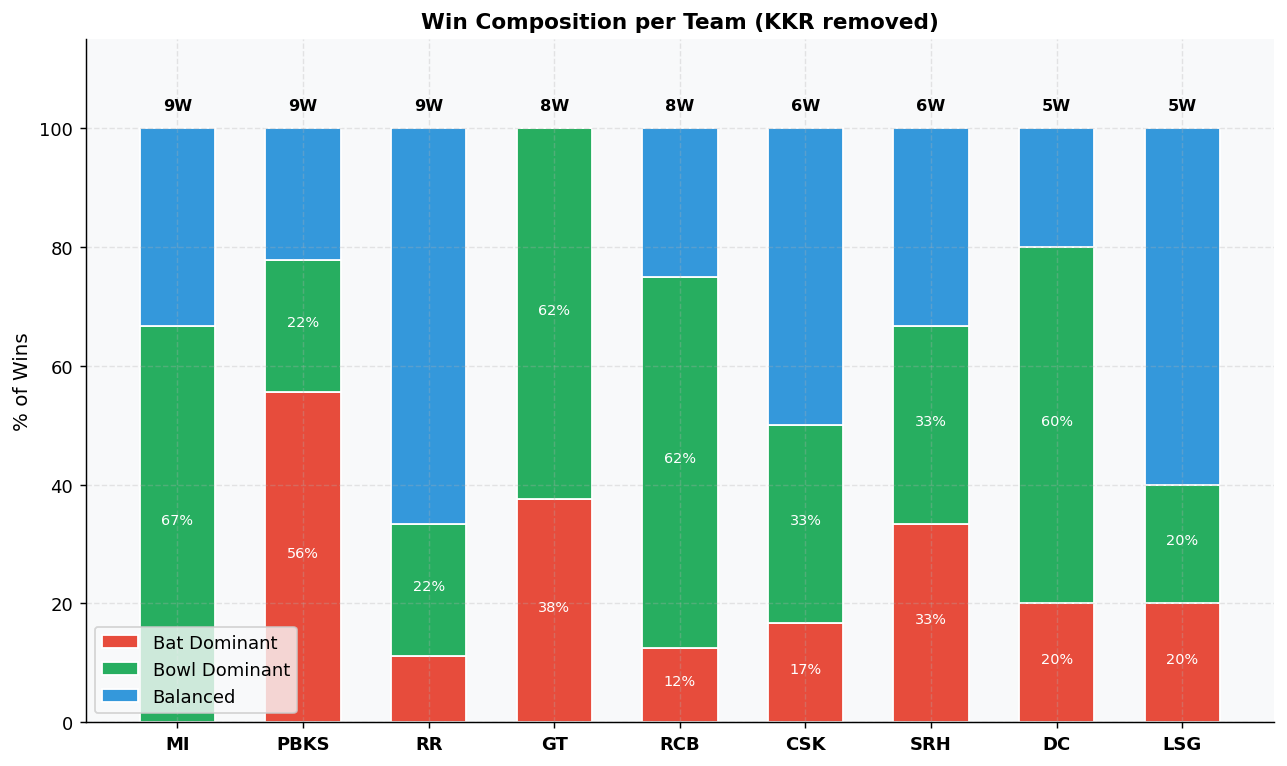

In [103]:
# Remove KKR
wdf = wdf[wdf["team"] != "KKR"].reset_index(drop=True)

plt.figure(figsize=(10, 6))

x = np.arange(len(wdf))
w = 0.6

# Stacked bars
plt.bar(x, wdf['bat_pct'], width=w,
        color='#E74C3C', edgecolor='white',
        label='Bat Dominant')

plt.bar(x, wdf['bowl_pct'], width=w,
        bottom=wdf['bat_pct'],
        color='#27AE60', edgecolor='white',
        label='Bowl Dominant')

plt.bar(x, wdf['bal_pct'], width=w,
        bottom=wdf['bat_pct'] + wdf['bowl_pct'],
        color='#3498DB', edgecolor='white',
        label='Balanced')

# Total wins annotation
for i, row in enumerate(wdf.itertuples()):
    plt.text(i, 103, f'{row.total_wins}W',
             ha='center', fontsize=9, fontweight='bold')

# % labels
for i, row in enumerate(wdf.itertuples()):
    if row.bat_pct > 12:
        plt.text(i, row.bat_pct/2, f'{row.bat_pct:.0f}%',
                 ha='center', color='white', fontsize=8)
    if row.bowl_pct > 12:
        plt.text(i, row.bat_pct + row.bowl_pct/2, f'{row.bowl_pct:.0f}%',
                 ha='center', color='white', fontsize=8)

# Axis
plt.xticks(x, wdf['team'], fontsize=10, fontweight='bold')

plt.ylabel("% of Wins")
plt.ylim(0, 115)

plt.title("Win Composition per Team (KKR removed)")
plt.legend()

plt.tight_layout()
plt.show()